# Automatic Ring–Board press/lift alignment

This notebook estimates one constant offset in the model `ring_time = board_time + offset`. It detects Board press and lift transitions, dynamically selects the Board interval, detects unlabeled Ring motion-transient peak regions, and monotonically matches the complete valid Board event sequence to distinct Ring peak regions.

Board supplies the press/lift labels. Ring peaks are unlabeled motion transients—not a trained press/lift classifier—and a match must not be interpreted as definitive physical contact. Raw Ring and Board timestamps are never modified in place. Manual anchors and the older group-consensus candidate are not authoritative in this workflow.

In [45]:
from __future__ import annotations

from dataclasses import asdict, replace
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from writingring import (
    AlignmentConfig,
    AlignmentFailureError,
    GravityRemovalConfig,
    PeakDetectionConfig,
    StationarySearchConfig,
    align_events_to_transient_peaks,
    compute_transient_score,
    detect_board_events,
    detect_transient_peak_regions,
    discover_recordings,
    load_board,
    load_ring,
    plot_alignment_residuals,
    plot_imu_with_board_events,
    plot_transient_with_event_raster,
    process_ring_gravity,
    select_board_interval_from_presses,
    select_recording,
    smooth_transient_score,
)

## Configuration

Interval selection begins three seconds before the first valid touch press, clamped to the first available Board frame, and ends three seconds after the 20th valid press, or after the final valid press when fewer than 20 exist. No later cell overwrites these values.

`USE_GRAVITY_REMOVAL` selects raw or gravity-removed IMU inputs. `RAW_TRANSIENT_SIGNAL_COLUMNS` and `GRAVITY_REMOVED_TRANSIENT_SIGNAL_COLUMNS` independently configure which axes contribute to the score, while the plot-column tuples retain the six diagnostic rows. `MATCH_EVENT_MODE` selects press-only (`press_only`) or press-and-lift (`press_lift`) alignment; plots always retain both Board event types. All gravity, stationary-search, smoothing, peak, and alignment settings are defined in this cell.

In [ ]:
USER = "user_2"
ACTION = "0"
DATASET_ID = 0

RAW_SIGNAL_COLUMNS = (
    "acc_x",
    "acc_y",
    "acc_z",
    "gyr_x",
    "gyr_y",
    "gyr_z",
)
RAW_TRANSIENT_SIGNAL_COLUMNS = (
    "acc_x",
    "acc_y",
    "acc_z",
    "gyr_x",
    "gyr_y",
    "gyr_z",
)
GRAVITY_REMOVED_SIGNAL_COLUMNS = (
    "linear_acc_body_x",
    "linear_acc_body_y",
    "linear_acc_body_z",
    "angular_velocity_body_x_rad_s",
    "angular_velocity_body_y_rad_s",
    "angular_velocity_body_z_rad_s",
)
GRAVITY_REMOVED_TRANSIENT_SIGNAL_COLUMNS = (
    "linear_acc_body_x",
    "linear_acc_body_y",
    "linear_acc_body_z",
    "angular_velocity_body_x_rad_s",
    "angular_velocity_body_y_rad_s",
    "angular_velocity_body_z_rad_s",
)
MATCH_EVENT_MODE = "press_only"  # "press_only" or "press_lift"
USE_GRAVITY_REMOVAL = True
GRAVITY_CONFIG_TEMPLATE = GravityRemovalConfig(
    sampling_rate_hz=200.0,  # replaced by the observed recording rate
    acceleration_scale_to_working_units=1.0,
    acceleration_unit_label="m/s^2 (assumed)",
    gyro_scale_to_rad_s=1.0,
    correction_time_constant_s=1.0,
    acceleration_gate_relative_tolerance=0.15,
    angular_rate_gate_rad_s=None,
    strict_calibration=False,
)
STATIONARY_SEARCH_CONFIG_TEMPLATE = StationarySearchConfig(
    sampling_rate_hz=200.0,  # replaced by the observed recording rate
    stationary_duration_s=0.2,
    stride_duration_s=0.05,
    prefer_passing_window=False,
)
TARGET_VALID_PRESS_COUNT = 20
SECONDS_BEFORE_FIRST_VALID_TOUCH = 3.0
SECONDS_AFTER_TARGET_PRESS = 3.0
MINIMUM_TOUCH_DURATION_FRAMES = 3
PREVIEW_DURATION_S = 30.0
TRANSIENT_SMOOTHING_WINDOW_SAMPLES = 3

PEAK_CONFIG = PeakDetectionConfig(
    smoothing_window_samples=1,
    prominence_window_samples=60,
    prominence_mad_multiplier=3.0,
    minimum_prominence=0.5,
    boundary_prominence_fraction=0.6,
    merge_gap_samples=6,
)
ALIGNMENT_CONFIG = AlignmentConfig(
    offset_search_range_us=(-2_000_000.0, 2_000_000.0),
    offset_cluster_width_us=20_000.0,
    maximum_offset_candidates=100,
    minimum_event_coverage_ratio=0.40,
    minimum_valid_touch_pairs=5,
    ambiguity_distance_margin=0.03,
    press_lift_coverage_difference_warning=0.20,
    residual_trend_warning_ms=10.0,
    outside_ring_fraction_warning=0.20,
    touch_duration_difference_warning_ms=150.0,
)

## Discover and load one recording

In [47]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
preferred_data_root = PROJECT_ROOT / "data_sample" / "data"
legacy_data_root = PROJECT_ROOT / "data"
path_warnings: list[str] = []
if preferred_data_root.is_dir():
    DATA_ROOT = preferred_data_root
elif legacy_data_root.is_dir():
    DATA_ROOT = legacy_data_root
    path_warnings.append(
        "Configured sample root data_sample/data is absent; using supplied data/."
    )
else:
    raise FileNotFoundError("Neither data_sample/data nor data exists")

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "alignment"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
recordings = discover_recordings(DATA_ROOT)
recording = select_recording(
    recordings,
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
)
if recording.board_chunk_indices != tuple(sorted(recording.board_chunk_indices)):
    raise AssertionError("Board chunks are not in numeric chunk-index order")

ring_data = load_ring(recording)
board_data = load_board(recording)
print(f"Selected: {USER} / action {ACTION} / dataset {DATASET_ID}")
print(f"Ring source: {ring_data.source_path.name}")
print(f"Board chunks: {recording.board_chunk_indices}")
for warning in path_warnings:
    print(f"WARNING: {warning}")

Selected: user_2 / action 0 / dataset 0
Ring source: 0_ring_0.bin
Board chunks: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14)


## Detect all Board events and dynamically select the interval

Occupancy is `contact_count > 0`. The initial occupancy state is preserved, so an initially occupied first frame does not create a synthetic press. Each press is paired with the first subsequent lift before another press. Short pairs remain in diagnostics as transient/bounce events; unmatched presses remain explicitly incomplete.

Dataset 0's older timestamp tail is still present in the all-event table. Interval selection reports the backward boundary and uses the initial nondecreasing segment without repairing or reordering source data.

In [48]:
event_detection = detect_board_events(
    board_data.frames,
    minimum_duration_frames=MINIMUM_TOUCH_DURATION_FRAMES,
)
interval_selection = select_board_interval_from_presses(
    board_data.frames,
    board_data.contacts,
    event_detection,
    target_valid_press_count=TARGET_VALID_PRESS_COUNT,
    seconds_before_first_valid_touch=SECONDS_BEFORE_FIRST_VALID_TOUCH,
    seconds_after_press=SECONDS_AFTER_TARGET_PRESS,
)

board_events_all = event_detection.events
board_events_selected = interval_selection.events
board_touch_pairs = event_detection.touch_pairs
selected_touch_pairs = interval_selection.touch_pairs
board_interval_metadata = interval_selection.metadata

board_events_all_path = OUTPUT_DIR / "board_events_all.csv"
board_events_selected_path = OUTPUT_DIR / "board_events_selected.csv"
board_touch_pairs_path = OUTPUT_DIR / "board_touch_pairs.csv"
board_interval_metadata_path = OUTPUT_DIR / "board_interval_metadata.json"
board_events_all.to_csv(board_events_all_path, index=False)
board_events_selected.to_csv(board_events_selected_path, index=False)
board_touch_pairs.to_csv(board_touch_pairs_path, index=False)
board_interval_metadata_path.write_text(
    json.dumps(board_interval_metadata, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(board_interval_metadata, indent=2))
for warning in interval_selection.warnings:
    print(f"WARNING: {warning}")
display(board_events_selected)
display(selected_touch_pairs)

{
  "board_start_timestamp": 1720653458673257,
  "desired_board_start_timestamp": 1720653457087597,
  "first_available_board_timestamp": 1720653458673257,
  "first_valid_touch_press_timestamp": 1720653460087597,
  "seconds_before_first_valid_touch": 3.0,
  "start_was_clamped": true,
  "desired_board_end_timestamp": 1720653528598073,
  "actual_board_end_timestamp": 1720653528598073,
  "valid_press_count_available": 34,
  "valid_press_count_selected": 21,
  "selected_event_count": 42,
  "selected_press_count": 21,
  "selected_lift_count": 21,
  "end_was_clamped": false,
  "selected_interval_duration_s": 69.924816,
  "target_valid_press_count": 20,
  "seconds_after_target_press": 3.0,
  "boundary_press_event_index": 38,
  "boundary_press_lift_in_interval": true,
  "last_selected_press_event_index": 40,
  "last_selected_press_lift_in_interval": true,
  "backward_jump_count_in_full_board_order": 0
}


,event_index,event_type,global_frame_index,frame_timestamp_raw,chunk_index,contact_count,paired_touch_index,duration_frames,transient,valid_touch,incomplete_touch
0,0,press,194,1720653460087597,1,1,0,147,False,True,False
1,1,lift,341,1720653461250414,1,0,0,147,False,True,False
2,2,press,1813,1720653471978374,2,1,1,82,False,True,False
3,3,lift,1895,1720653472622261,2,0,1,82,False,True,False
4,4,press,2646,1720653478095875,3,1,2,50,False,True,False
5,5,lift,2696,1720653478489299,3,0,2,50,False,True,False
6,6,press,2723,1720653478687102,3,1,3,20,False,True,False
7,7,lift,2743,1720653478842889,3,0,3,20,False,True,False
8,8,press,3070,1720653481225663,4,1,4,76,False,True,False
9,9,lift,3146,1720653481825178,4,0,4,76,False,True,False


,paired_touch_index,press_event_index,lift_event_index,press_global_frame_index,lift_global_frame_index,press_timestamp_raw,lift_timestamp_raw,duration_frames,duration_s,transient,valid_touch,incomplete_touch,press_in_selected_interval,lift_in_selected_interval
0,0,0,1,194,341,1720653460087597,1720653461250414,147,1.162817,False,True,False,True,True
1,1,2,3,1813,1895,1720653471978374,1720653472622261,82,0.643887,False,True,False,True,True
2,2,4,5,2646,2696,1720653478095875,1720653478489299,50,0.393424,False,True,False,True,True
3,3,6,7,2723,2743,1720653478687102,1720653478842889,20,0.155787,False,True,False,True,True
4,4,8,9,3070,3146,1720653481225663,1720653481825178,76,0.599515,False,True,False,True,True
5,5,10,11,4323,4344,1720653490402319,1720653490567020,21,0.164701,False,True,False,True,True
6,6,12,13,4372,4445,1720653490772195,1720653491347337,73,0.575142,False,True,False,True,True
7,7,14,15,4882,4918,1720653494532765,1720653494813497,36,0.280732,False,True,False,True,True
8,8,16,17,4944,5015,1720653495003961,1720653495562106,71,0.558145,False,True,False,True,True
9,9,18,19,5587,5704,1720653499734722,1720653500654009,117,0.919287,False,True,False,True,True


## Reconstructed Ring axis and motion-transient score

Raw `timestamp` remains unchanged. Because it contains duplicates, a separately named strictly increasing working axis is reconstructed using the recording-specific endpoint-observed sampling rate under an explicit microsecond interpretation.

`transient_score_raw` is the Euclidean norm of median/MAD-normalized first differences across the six active IMU channels. Those channels are raw `acc/gyr` when gravity removal is disabled, or `linear_acc_body/angular_velocity_body` when enabled. `transient_score` uses the configured centered moving-average window consistently for plotting, peak detection, and matching.

In [49]:
ring_timestamps_raw = ring_data.dataframe["timestamp"].to_numpy(copy=True)
sample_count = len(ring_timestamps_raw)
if sample_count < 3:
    raise ValueError("At least three Ring samples are required")
duration_s = (
    ring_timestamps_raw[-1] - ring_timestamps_raw[0]
) / 1_000_000.0
if not np.isfinite(duration_s) or duration_s <= 0.0:
    raise ValueError("Ring endpoint duration must be finite and positive")
imu_sampling_rate_hz = float((sample_count - 1) / duration_s)
ring_timestamp_reconstructed = (
    ring_timestamps_raw[0]
    + np.arange(sample_count, dtype=float)
    * 1_000_000.0
    / imu_sampling_rate_hz
)
ring_dataframe = ring_data.dataframe.copy()
gravity_result = None
gravity_warnings: list[str] = []
if USE_GRAVITY_REMOVAL:
    gravity_config = replace(
        GRAVITY_CONFIG_TEMPLATE,
        sampling_rate_hz=imu_sampling_rate_hz,
    )
    stationary_search_config = replace(
        STATIONARY_SEARCH_CONFIG_TEMPLATE,
        sampling_rate_hz=imu_sampling_rate_hz,
    )
    gravity_result = process_ring_gravity(
        ring_data,
        config=gravity_config,
        stationary_search_config=stationary_search_config,
    )
    gravity_dataframe = gravity_result.to_dataframe(index=ring_dataframe.index)
    ring_dataframe = pd.concat([ring_dataframe, gravity_dataframe], axis=1)
    active_plot_signal_columns = GRAVITY_REMOVED_SIGNAL_COLUMNS
    active_transient_signal_columns = (
        GRAVITY_REMOVED_TRANSIENT_SIGNAL_COLUMNS
    )
    gravity_warnings.extend(gravity_result.diagnostics.warnings)
    gravity_search = gravity_result.calibration.stationary_search
else:
    gravity_config = None
    stationary_search_config = None
    gravity_search = None
    active_plot_signal_columns = RAW_SIGNAL_COLUMNS
    active_transient_signal_columns = RAW_TRANSIENT_SIGNAL_COLUMNS
ring_dataframe["ring_timestamp_reconstructed"] = ring_timestamp_reconstructed
transient_score_raw = compute_transient_score(
    ring_dataframe,
    signal_columns=active_transient_signal_columns,
)
transient_score = smooth_transient_score(
    transient_score_raw,
    window_samples=TRANSIENT_SMOOTHING_WINDOW_SAMPLES,
)
ring_dataframe["transient_score_raw"] = transient_score_raw
ring_dataframe["transient_score"] = transient_score

print(f"Ring sampling rate: {imu_sampling_rate_hz:.6f} Hz")
print("Raw Ring timestamps retained; reconstructed axis is separate and monotonic.")
print(f"Gravity removal enabled: {USE_GRAVITY_REMOVAL}")
print(f"Plot IMU columns: {active_plot_signal_columns}")
print(f"Transient-score columns: {active_transient_signal_columns}")
if gravity_search is not None:
    print(
        f"Gravity calibration window: [{gravity_search.start_index}, "
        f"{gravity_search.stop_index}), score={gravity_search.score:.6f}, "
        f"passed={gravity_search.passed}, "
        f"provisional={gravity_result.diagnostics.provisional}"
    )
for warning in gravity_warnings:
    print(f"WARNING: {warning}")

Ring sampling rate: 200.913234 Hz
Raw Ring timestamps retained; reconstructed axis is separate and monotonic.
Gravity removal enabled: True
Active IMU columns: ('linear_acc_body_x', 'linear_acc_body_y', 'linear_acc_body_z', 'angular_velocity_body_x_rad_s', 'angular_velocity_body_y_rad_s', 'angular_velocity_body_z_rad_s')
Gravity calibration window: [6470, 6510), score=1.582382, passed=True, provisional=False


## Before alignment: preserve the original clock offset

Both figures use Ring reconstructed start as the common zero. Board event positions are `(board_timestamp - ring_start) / 1e6`; the Board start is not subtracted independently. Off-screen press/lift counts are printed rather than silently omitted.

Before-alignment visibility: {'press_inside': 5, 'press_outside': 16, 'lift_inside': 4, 'lift_outside': 17}


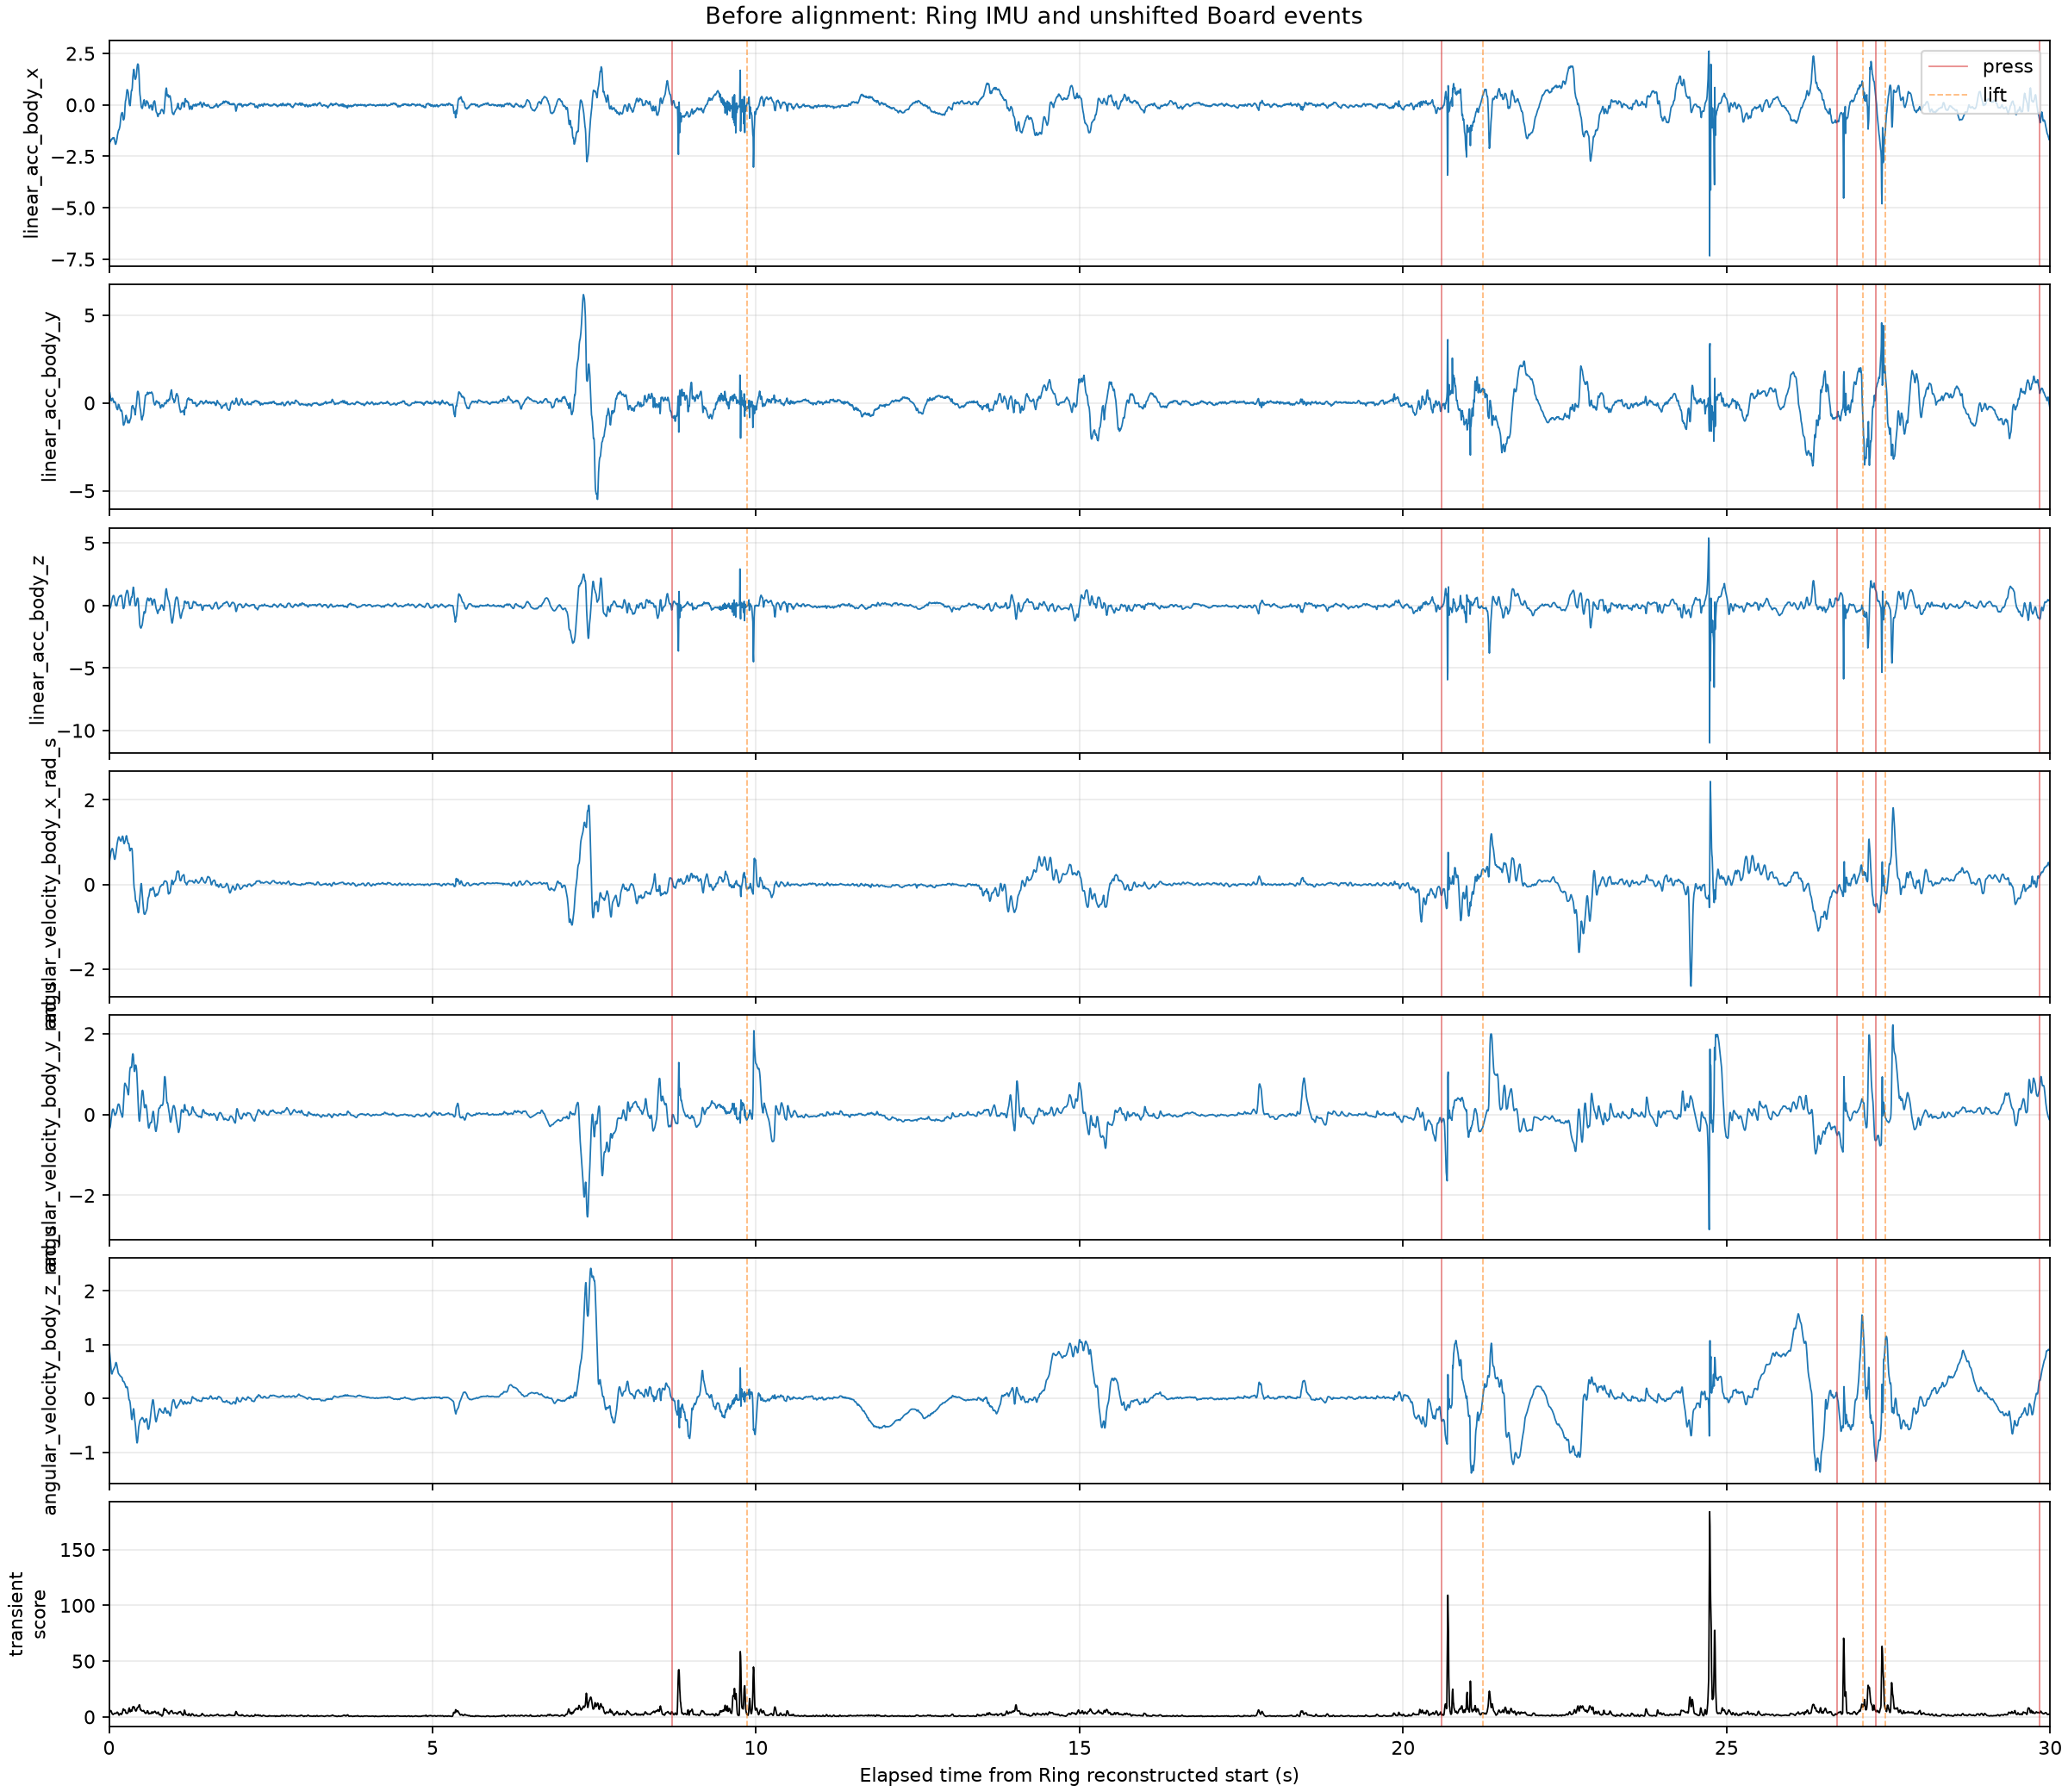

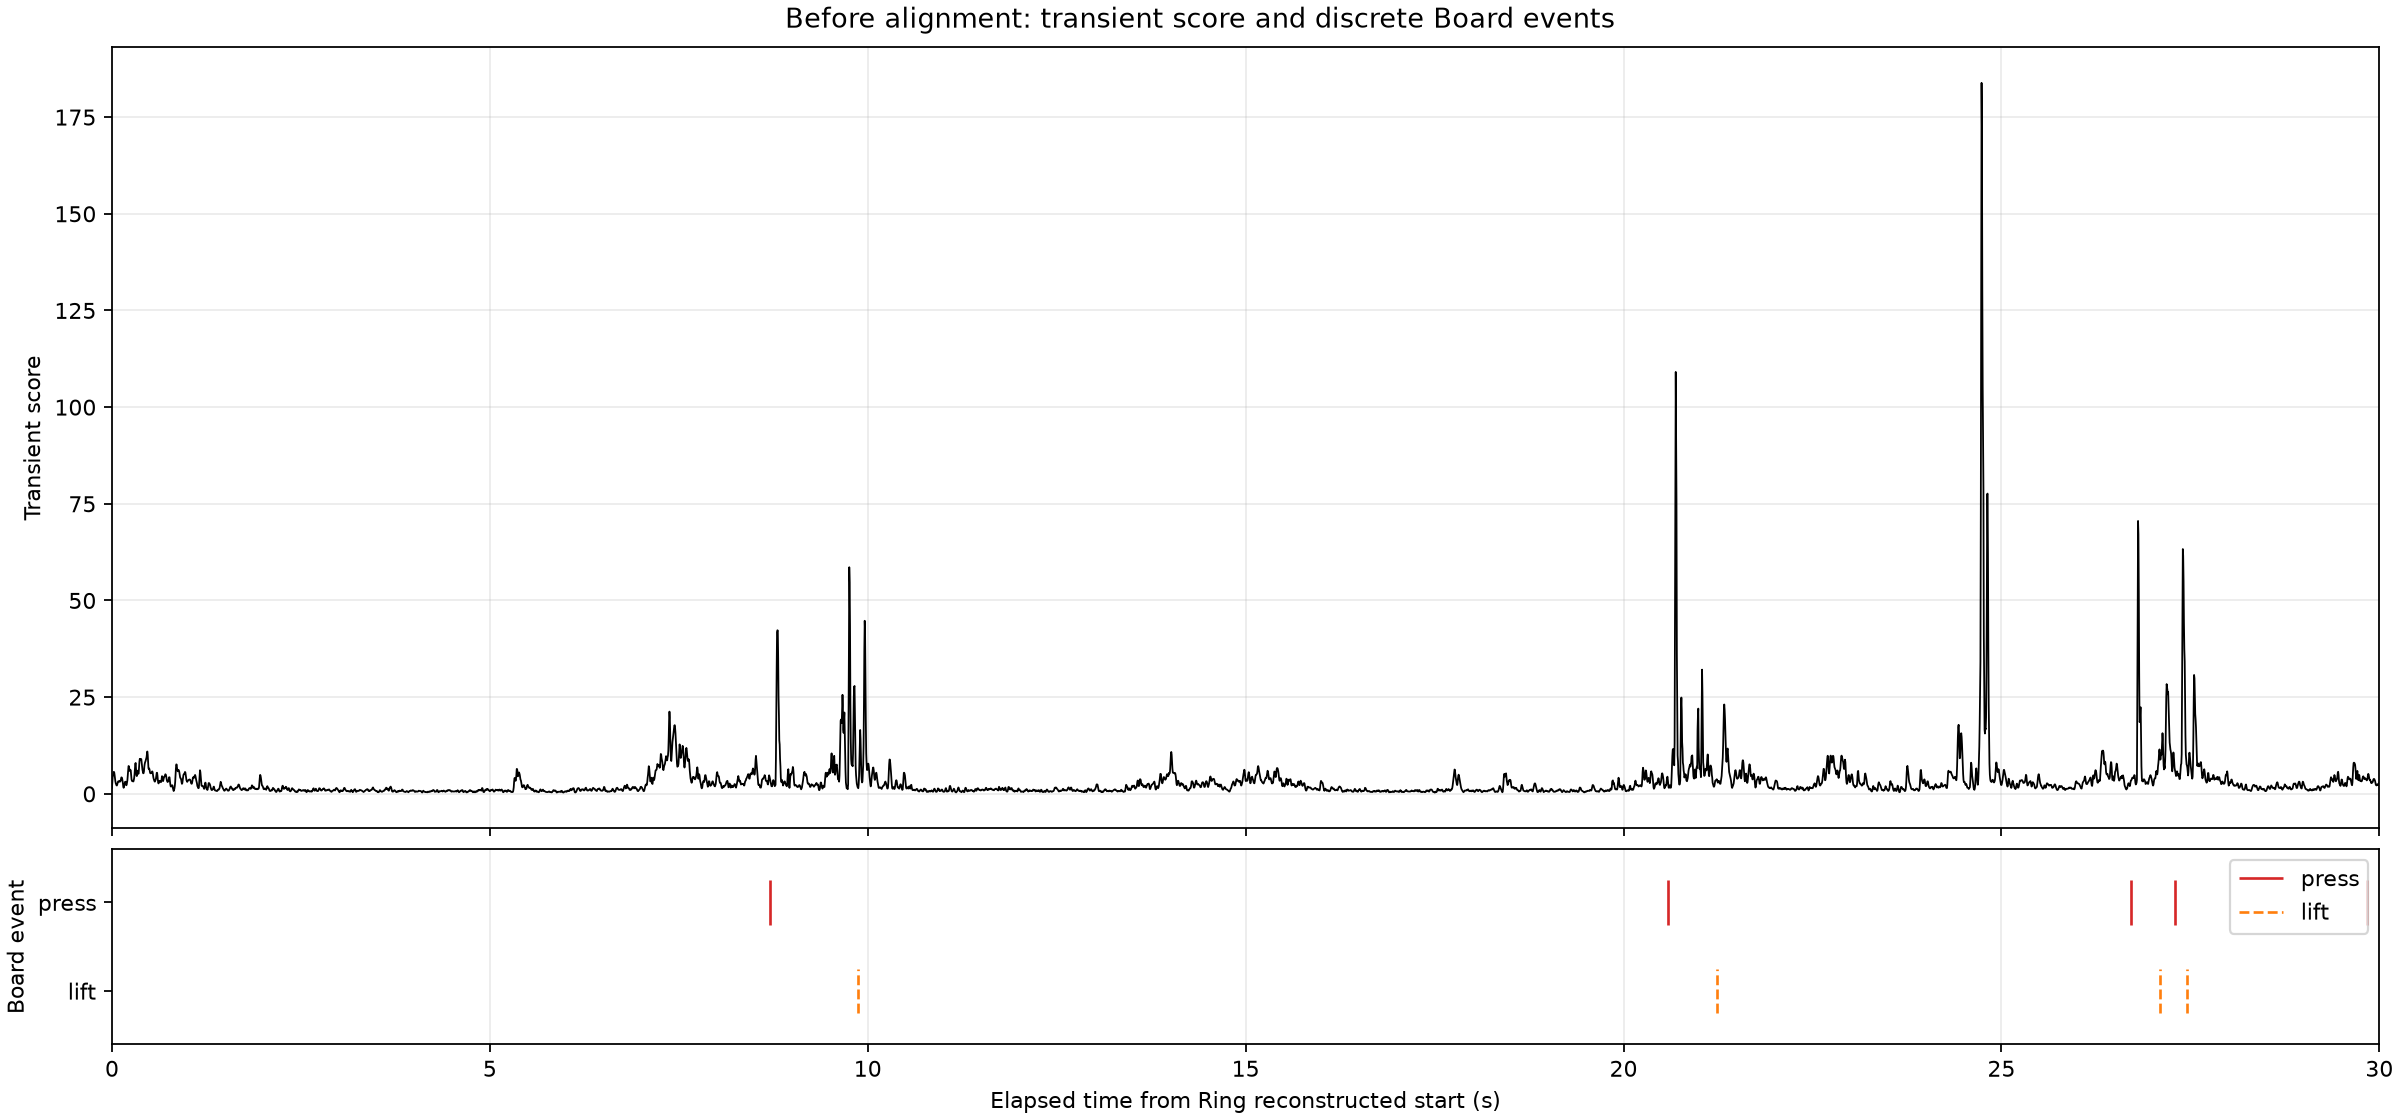

In [50]:
before_imu_path = OUTPUT_DIR / "before_alignment_imu_events_30s.png"
before_transient_path = OUTPUT_DIR / "before_alignment_transient_events_30s.png"
before_imu_figure, before_visibility = plot_imu_with_board_events(
    ring_dataframe,
    ring_timestamp_reconstructed,
    transient_score,
    board_events_selected,
    signal_columns=active_plot_signal_columns,
    offset_us=0.0,
    duration_s=PREVIEW_DURATION_S,
    title="Before alignment: Ring IMU and unshifted Board events",
    output_path=before_imu_path,
    show=False,
)
plt.close(before_imu_figure)
before_transient_figure, before_raster_visibility = (
    plot_transient_with_event_raster(
        ring_timestamp_reconstructed,
        transient_score,
        board_events_selected,
        offset_us=0.0,
        duration_s=PREVIEW_DURATION_S,
        title="Before alignment: transient score and discrete Board events",
        output_path=before_transient_path,
        show=False,
    )
)
plt.close(before_transient_figure)
assert before_visibility == before_raster_visibility
print(f"Before-alignment visibility: {asdict(before_visibility)}")
display(Image(filename=str(before_imu_path)))
display(Image(filename=str(before_transient_path)))

## Detect unlabeled transient peak regions

The configured smoothed six-axis transient score is used consistently here and in the plots. Local maxima must pass a robust MAD-scaled prominence threshold. Each region is bounded at a configured fraction of its prominence, and nearby regions are merged when separated by no more than the configured sample gap. The unsmoothed score remains available as `transient_score_raw` for diagnostics.

In [51]:
transient_peak_regions = detect_transient_peak_regions(
    transient_score,
    ring_timestamp_reconstructed,
    config=PEAK_CONFIG,
)
transient_peak_regions_path = OUTPUT_DIR / "transient_peak_regions.csv"
transient_peak_regions.to_csv(transient_peak_regions_path, index=False)
print(f"Detected {len(transient_peak_regions)} transient peak regions.")
display(transient_peak_regions)

Detected 164 transient peak regions.


,peak_index,peak_timestamp,peak_elapsed_s,left_index,right_index,left_timestamp,right_timestamp,width_s,height,prominence
0,94,1.720653e+15,0.467864,86,100,1.720653e+15,1.720653e+15,0.069682,10.952497,8.264255
1,1482,1.720653e+15,7.376319,1479,1501,1.720653e+15,1.720653e+15,0.109500,21.257863,18.399477
2,1712,1.720653e+15,8.521091,1697,1715,1.720653e+15,1.720653e+15,0.089591,9.819983,8.223258
3,1769,1.720653e+15,8.804796,1766,1773,1.720653e+15,1.720653e+15,0.034841,42.298440,40.706679
4,1942,1.720653e+15,9.665864,1905,1949,1.720653e+15,1.720653e+15,0.219000,25.601244,24.243848
...,...,...,...,...,...,...,...,...,...,...
159,20888,1.720654e+15,103.965277,20885,20904,1.720654e+15,1.720654e+15,0.094568,23.357583,19.805063
160,21248,1.720654e+15,105.757095,21246,21257,1.720654e+15,1.720654e+15,0.054750,203.777688,201.121528
161,21306,1.720654e+15,106.045777,21304,21307,1.720654e+15,1.720654e+15,0.014932,68.290660,65.634500
162,21336,1.720654e+15,106.195095,21327,21338,1.720654e+15,1.720654e+15,0.054750,11.374498,8.718337


## Automatic constant-offset sequence alignment

Candidate offsets are peak-center minus Board-event timestamps, reduced by deterministic histogram-style clustering. For each candidate, pair-aware dynamic programming matches valid press and lift events to distinct peak regions while preserving order. A match counts only when the shifted event lies inside that region.

Candidate ranking is lexicographic: matched-event coverage first, fully matched touch pairs second, peak-center proximity third, compressed `log1p(prominence)` fourth, and absolute offset only as the final tie-breaker. Unmatched events and peaks are allowed.

In [52]:
if MATCH_EVENT_MODE == "press_only":
    alignment_event_types = ("press",)
elif MATCH_EVENT_MODE == "press_lift":
    alignment_event_types = ("press", "lift")
else:
    raise ValueError(
        "MATCH_EVENT_MODE must be 'press_only' or 'press_lift', "
        f"got {MATCH_EVENT_MODE!r}"
    )
alignment_events = board_events_selected.loc[
    board_events_selected["event_type"].isin(alignment_event_types)
].copy()
print(
    f"Alignment event mode: {MATCH_EVENT_MODE}; "
    f"using {len(alignment_events)} event(s) of types {alignment_event_types}"
)
alignment_result = align_events_to_transient_peaks(
    alignment_events,
    selected_touch_pairs,
    transient_peak_regions,
    ring_timestamp_range=(
        float(ring_timestamp_reconstructed[0]),
        float(ring_timestamp_reconstructed[-1]),
    ),
    config=ALIGNMENT_CONFIG,
)
offset_candidates = alignment_result.candidates
event_peak_matches = alignment_result.event_matches
touch_pair_matches = alignment_result.touch_pair_matches

offset_candidates_path = OUTPUT_DIR / "offset_candidates.csv"
event_peak_matches_path = OUTPUT_DIR / "event_peak_matches.csv"
touch_pair_matches_path = OUTPUT_DIR / "touch_pair_matches.csv"
offset_candidates.to_csv(offset_candidates_path, index=False)
event_peak_matches.to_csv(event_peak_matches_path, index=False)
touch_pair_matches.to_csv(touch_pair_matches_path, index=False)

print(f"Best offset: {alignment_result.best_offset_us:.3f} us")
print(f"Second-best offset: {alignment_result.second_best_offset_us}")
print(json.dumps(alignment_result.report, indent=2))
display(offset_candidates.head(10))
display(event_peak_matches)
display(touch_pair_matches)

Alignment event mode: press_only; using 21 event(s) of types ('press',)
Best offset: 96665.250 us
Second-best offset: 104153.5
{
  "alignment_model": "constant_offset",
  "matched_event_types": [
    "press"
  ],
  "matching_objective": [
    "maximize matched event count",
    "minimize normalized distance to peak centers",
    "weakly maximize log1p peak prominence",
    "minimize absolute offset as final candidate tie-breaker"
  ],
  "pair_completeness_objective_enabled": false,
  "pair_aware_dynamic_programming": false,
  "structural_success": true,
  "alignment_success": true,
  "best_offset_us": 96665.25,
  "second_best_offset_us": 104153.5,
  "matched_event_count": 19,
  "total_valid_event_count": 21,
  "matched_press_count": 19,
  "total_valid_press_count": 21,
  "matched_lift_count": 0,
  "total_valid_lift_count": 0,
  "fully_matched_touch_pair_count": 0,
  "total_valid_touch_pair_count": 21,
  "event_coverage_ratio": 0.9047619047619048,
  "press_coverage_ratio": 0.90476190476

,rank,candidate_id,offset_us,absolute_offset_us,vote_count,matched_event_count,matched_press_count,matched_lift_count,fully_matched_touch_pair_count,median_normalized_peak_distance,maximum_normalized_peak_distance,total_normalized_peak_distance,mean_log1p_peak_prominence,outside_ring_event_count,matched_peak_count,total_peak_count,unmatched_peak_count,total_event_count,total_touch_pair_count,selected
0,1,0,96665.250,96665.250,16,19,19,0,0,0.156110,0.767623,4.574651,4.533307,0,19,164,145,21,21,True
1,2,6,104153.500,104153.500,3,17,17,0,0,0.243506,0.667324,5.012150,4.632981,0,17,164,147,21,21,False
2,3,26,739409.000,739409.000,2,8,8,0,0,0.701048,0.934640,4.541055,3.629315,0,8,164,156,21,21,False
3,4,27,748750.250,748750.250,2,7,7,0,0,0.164088,0.787615,2.557147,3.607642,0,7,164,157,21,21,False
4,5,62,848912.000,848912.000,1,7,7,0,0,0.718500,0.859798,4.244695,3.281664,0,7,164,157,21,21,False
5,6,11,-1477945.750,1477945.750,3,6,6,0,0,0.108318,0.386030,0.765902,4.173772,0,6,164,158,21,21,False
6,7,2,310794.625,310794.625,4,6,6,0,0,0.216410,0.411482,1.299521,3.041390,0,6,164,158,21,21,False
7,8,12,-1488965.250,1488965.250,3,6,6,0,0,0.224331,0.392747,1.282788,4.173772,0,6,164,158,21,21,False
8,9,5,-1630537.625,1630537.625,4,6,6,0,0,0.241524,0.605853,1.685193,3.704403,0,6,164,158,21,21,False
9,10,4,531255.000,531255.000,4,6,6,0,0,0.318279,0.589256,2.086452,3.511436,0,6,164,158,21,21,False


,event_index,event_type,paired_touch_index,board_timestamp_raw,shifted_event_timestamp,matched,matched_peak_index,matched_peak_timestamp,peak_left_timestamp,peak_right_timestamp,normalized_peak_distance,residual_us,peak_height,peak_prominence
0,0,press,0,1720653460087597,1.720653e+15,True,1769,1.720653e+15,1.720653e+15,1.720653e+15,0.352638,5265.50,42.298440,40.706679
1,2,press,1,1720653471978374,1.720653e+15,True,4157,1.720653e+15,1.720653e+15,1.720653e+15,0.004345,216.25,109.099826,106.721708
2,4,press,2,1720653478095875,1.720653e+15,True,5386,1.720653e+15,1.720653e+15,1.720653e+15,0.005431,-216.25,70.565027,68.430798
3,6,press,3,1720653478687102,1.720653e+15,True,5505,1.720653e+15,1.720653e+15,1.720653e+15,0.085615,852.25,63.297057,59.443948
4,8,press,4,1720653481225663,1.720653e+15,False,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10,press,5,1720653490402319,1.720653e+15,True,7859,1.720653e+15,1.720653e+15,1.720653e+15,0.214551,2135.75,120.665123,117.657835
6,12,press,6,1720653490772195,1.720653e+15,False,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,14,press,7,1720653494532765,1.720653e+15,True,8687,1.720653e+15,1.720653e+15,1.720653e+15,0.716083,-7128.25,64.137204,61.167110
8,16,press,8,1720653495003961,1.720653e+15,True,8782,1.720653e+15,1.720653e+15,1.720653e+15,0.550831,-5483.25,44.835194,42.084726
9,18,press,9,1720653499734722,1.720653e+15,True,9734,1.720653e+15,1.720653e+15,1.720653e+15,0.212919,2119.50,87.051862,84.137215


,paired_touch_index,press_event_index,lift_event_index,press_timestamp_raw,lift_timestamp_raw,touch_duration_ms,press_in_alignment,lift_in_alignment,matched_press_peak_index,matched_lift_peak_index,matched_press_peak_timestamp,matched_lift_peak_timestamp,press_residual_us,lift_residual_us,press_matched,lift_matched,both_events_matched,matched_peak_duration_ms,duration_difference_ms,reversed_peak_order
0,0,0,1,1720653460087597,1720653461250414,1162.817,True,False,1769,<NA>,1.720653e+15,NaN,5265.50,NaN,True,False,False,NaN,NaN,False
1,1,2,3,1720653471978374,1720653472622261,643.887,True,False,4157,<NA>,1.720653e+15,NaN,216.25,NaN,True,False,False,NaN,NaN,False
2,2,4,5,1720653478095875,1720653478489299,393.424,True,False,5386,<NA>,1.720653e+15,NaN,-216.25,NaN,True,False,False,NaN,NaN,False
3,3,6,7,1720653478687102,1720653478842889,155.787,True,False,5505,<NA>,1.720653e+15,NaN,852.25,NaN,True,False,False,NaN,NaN,False
4,4,8,9,1720653481225663,1720653481825178,599.515,True,False,<NA>,<NA>,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN,False
5,5,10,11,1720653490402319,1720653490567020,164.701,True,False,7859,<NA>,1.720653e+15,NaN,2135.75,NaN,True,False,False,NaN,NaN,False
6,6,12,13,1720653490772195,1720653491347337,575.142,True,False,<NA>,<NA>,NaN,NaN,NaN,NaN,False,False,False,NaN,NaN,False
7,7,14,15,1720653494532765,1720653494813497,280.732,True,False,8687,<NA>,1.720653e+15,NaN,-7128.25,NaN,True,False,False,NaN,NaN,False
8,8,16,17,1720653495003961,1720653495562106,558.145,True,False,8782,<NA>,1.720653e+15,NaN,-5483.25,NaN,True,False,False,NaN,NaN,False
9,9,18,19,1720653499734722,1720653500654009,919.287,True,False,9734,<NA>,1.720653e+15,NaN,2119.50,NaN,True,False,False,NaN,NaN,False


## After alignment and constant-offset residuals

The selected offset is applied only to plotted/matched Board event copies. Press and lift remain Board labels; Ring transients remain unlabeled. Matched residuals are peak-center minus shifted Board time. The dashed residual trend is diagnostic only—no affine or nonlinear correction is applied.

After-alignment visibility: {'press_inside': 5, 'press_outside': 16, 'lift_inside': 4, 'lift_outside': 17}


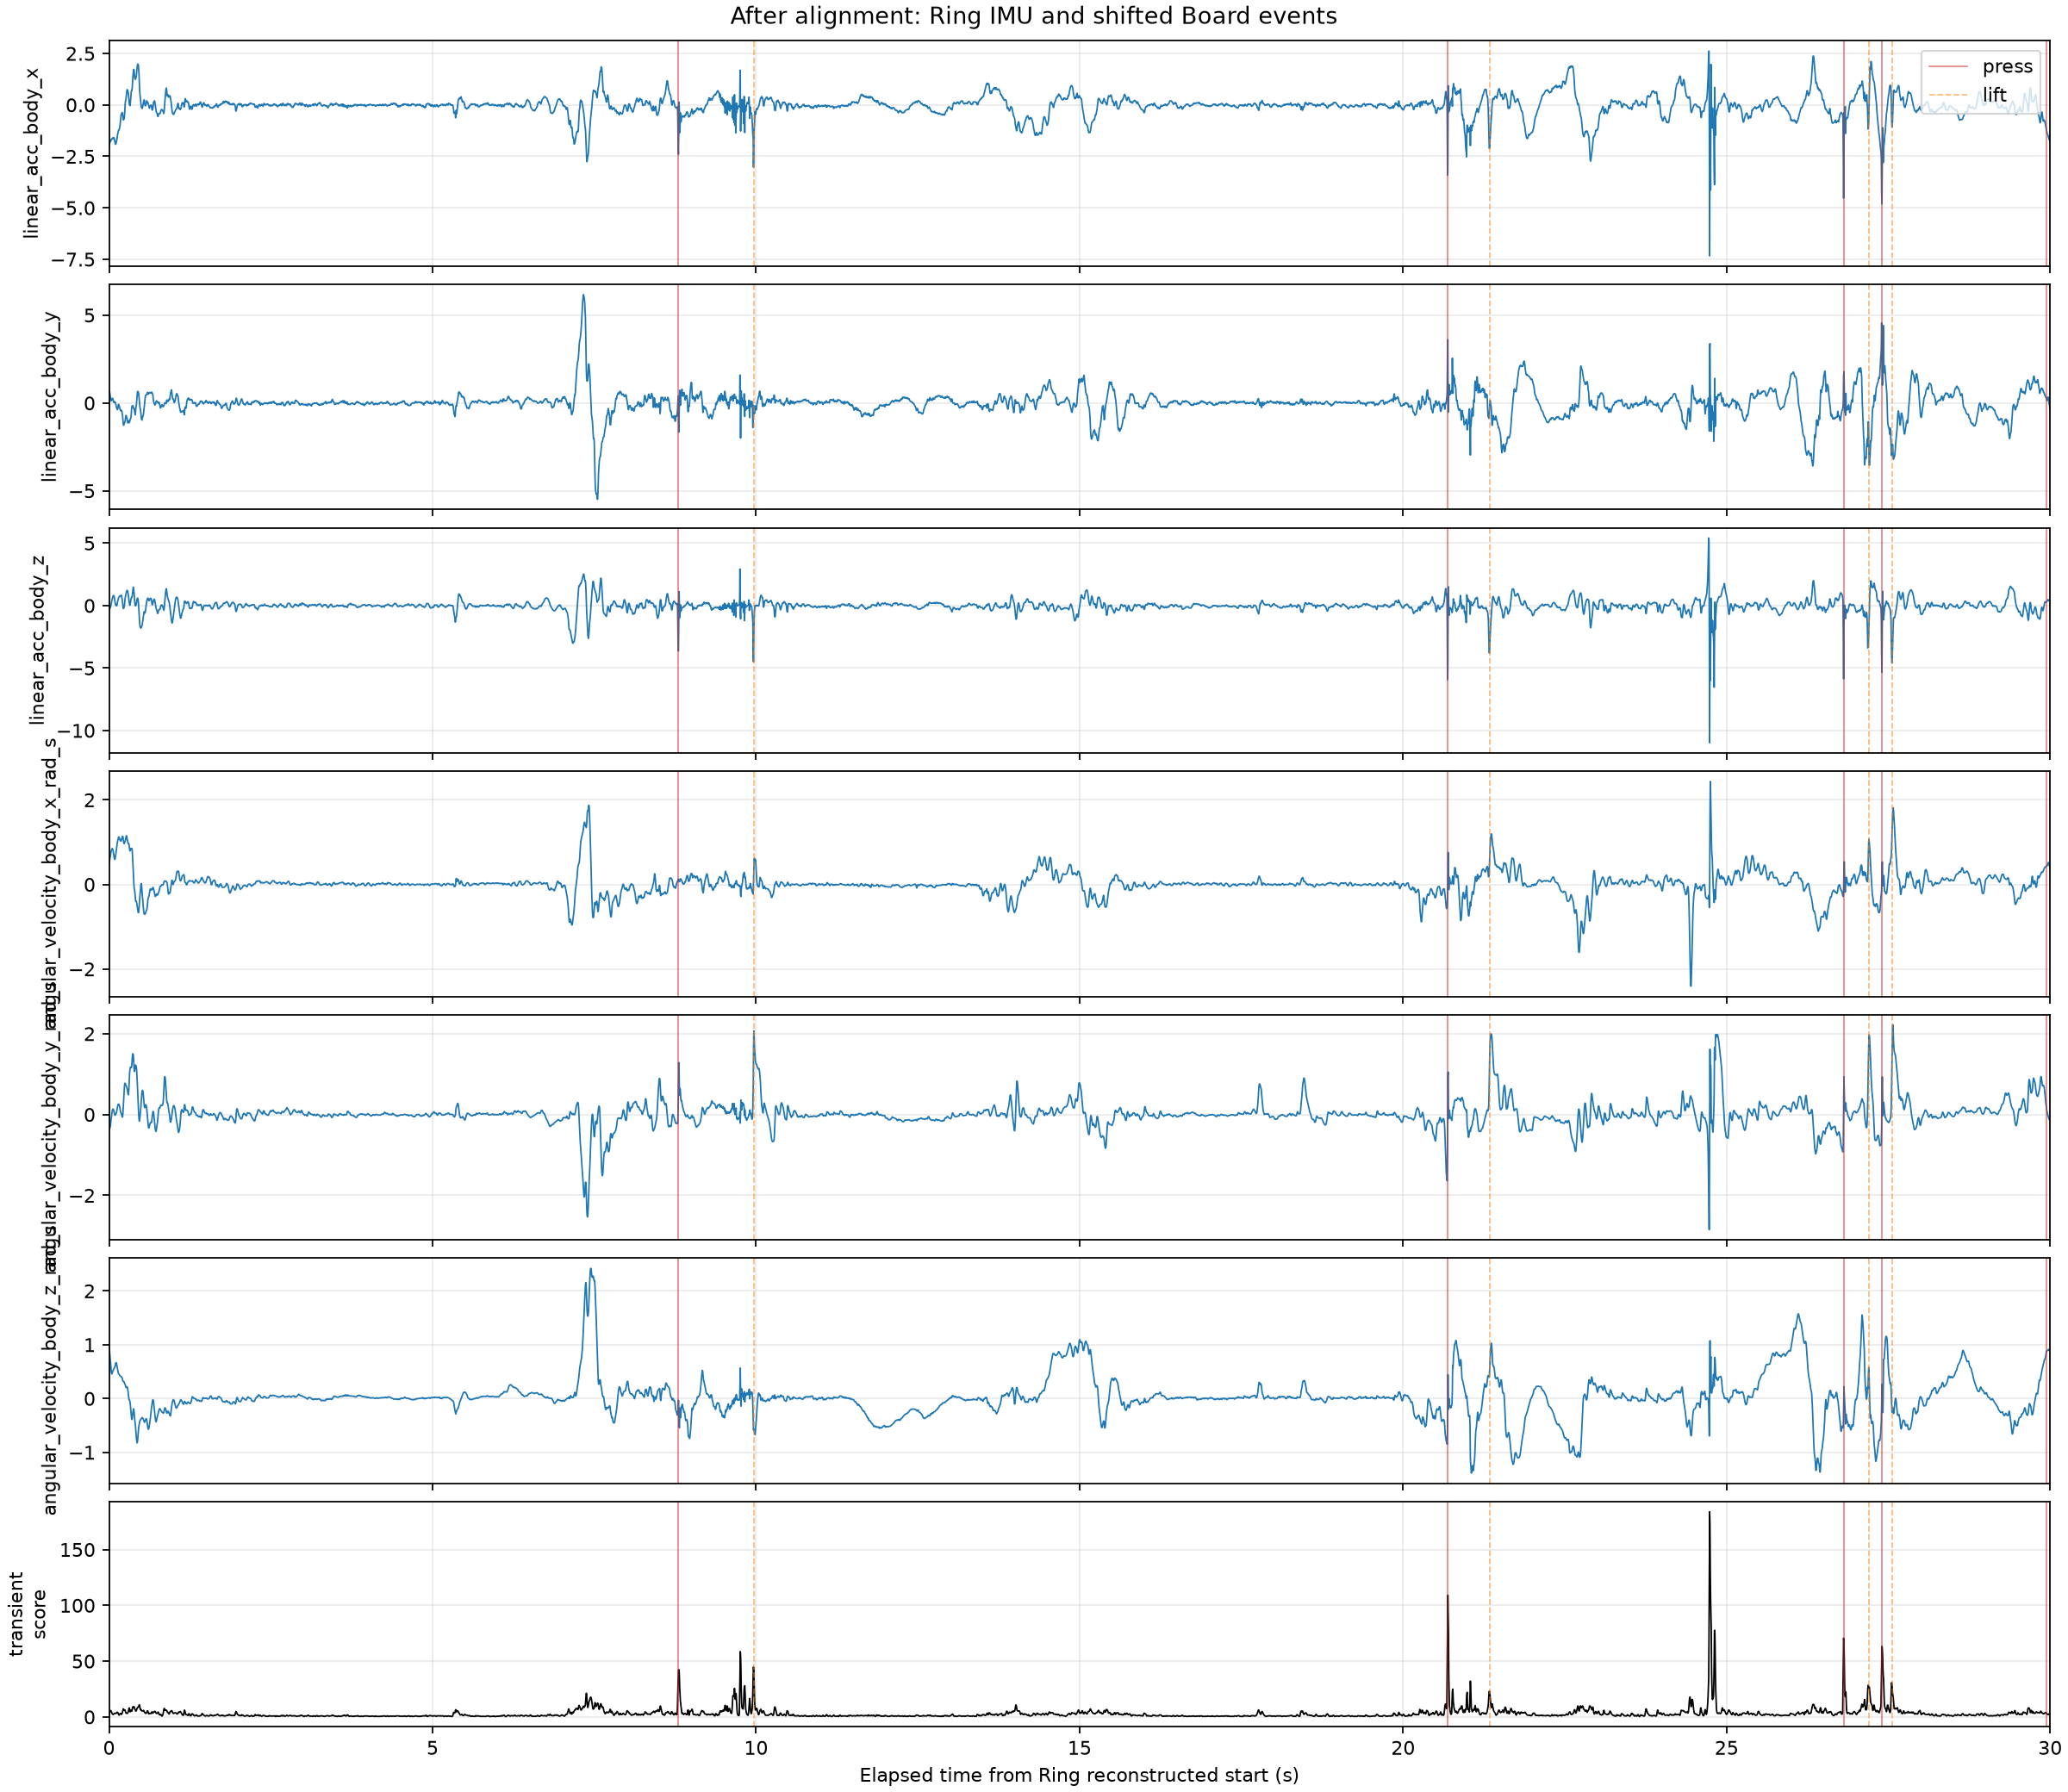

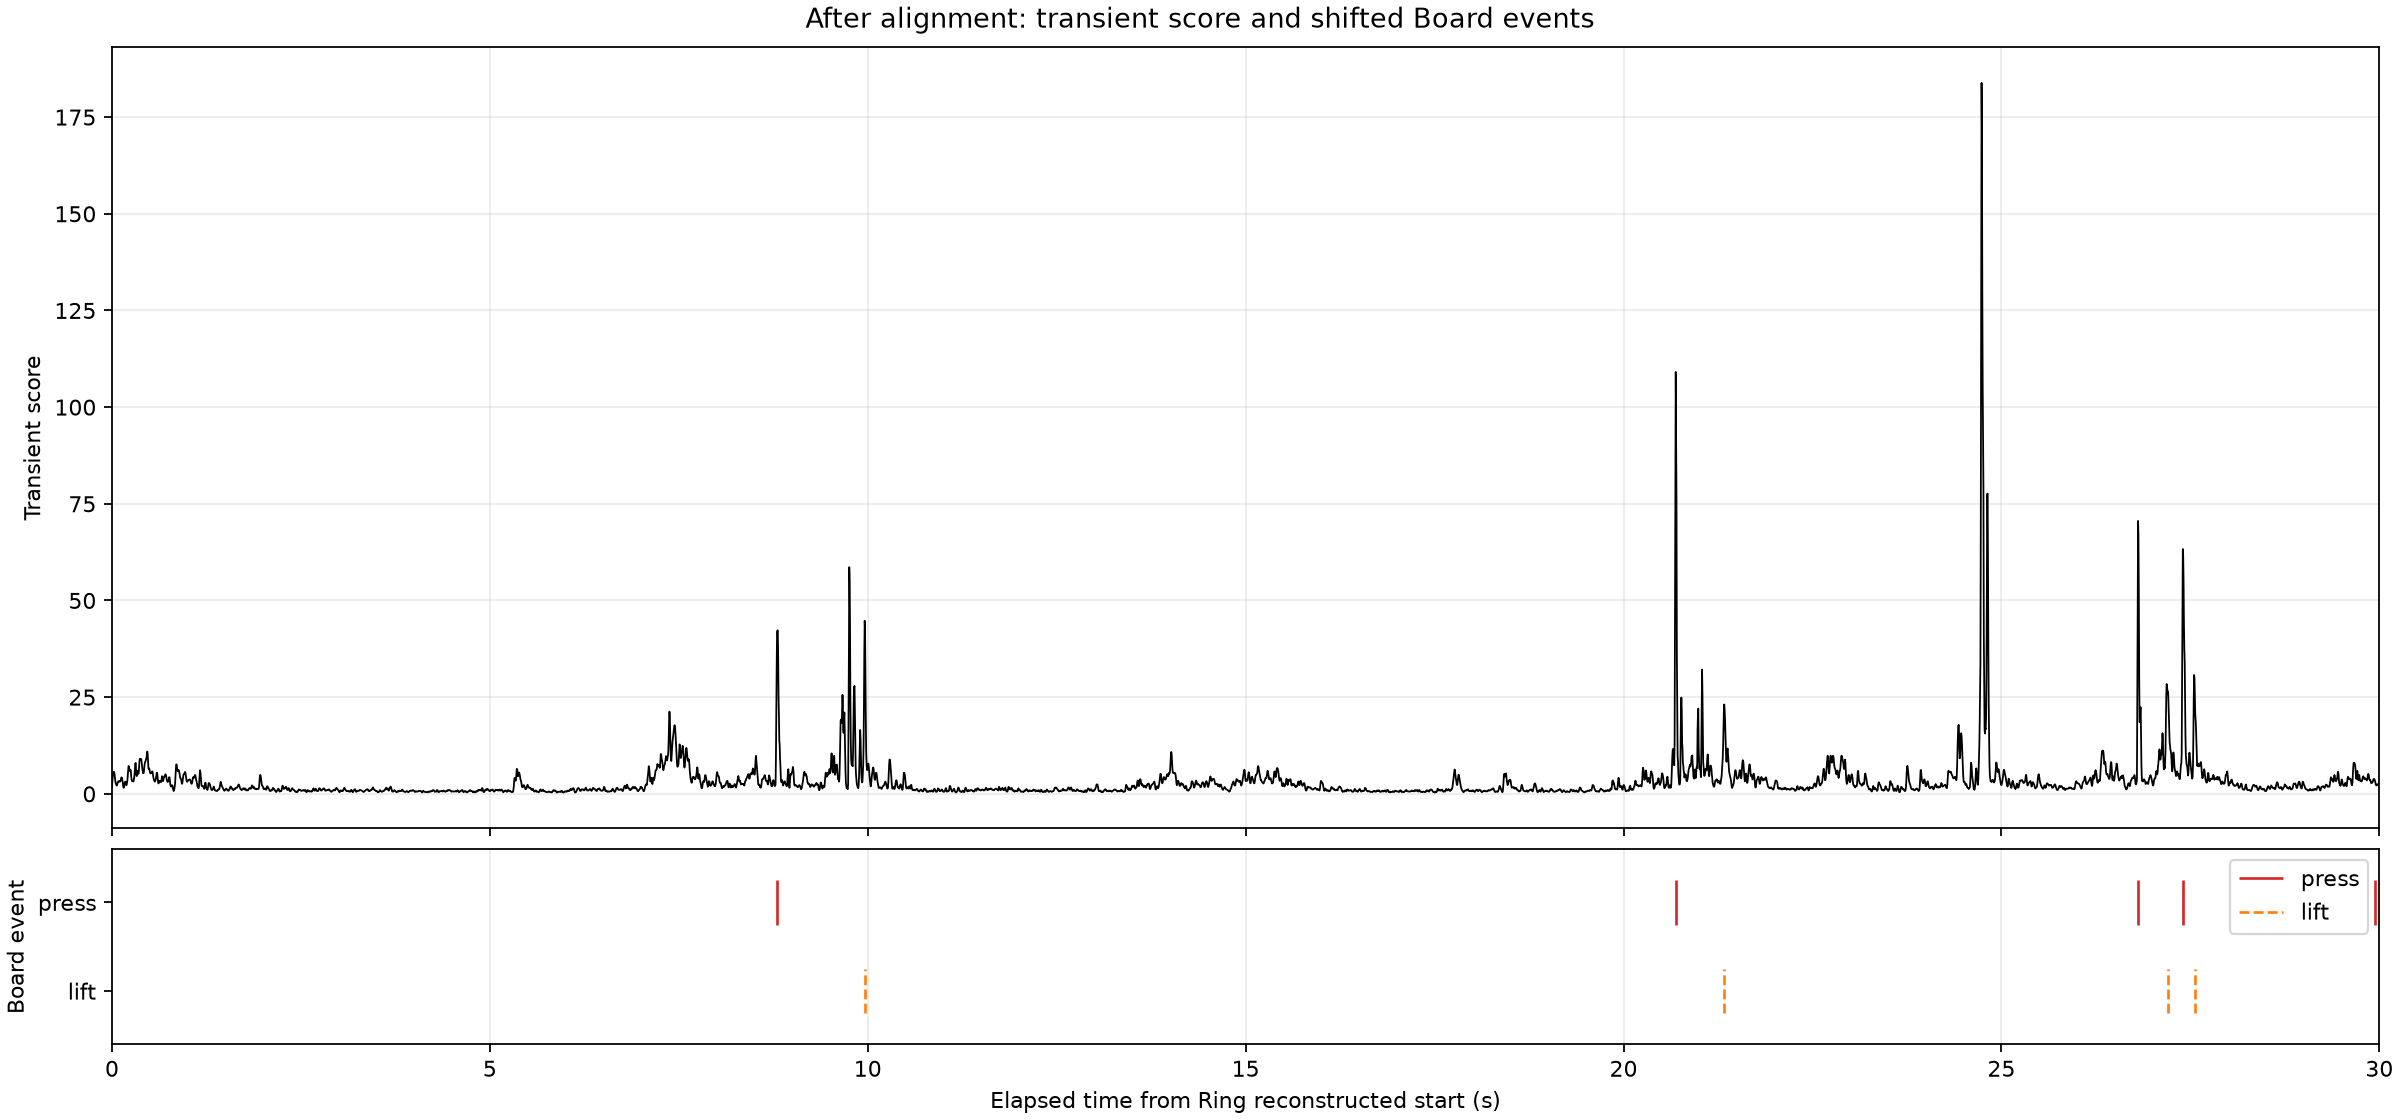

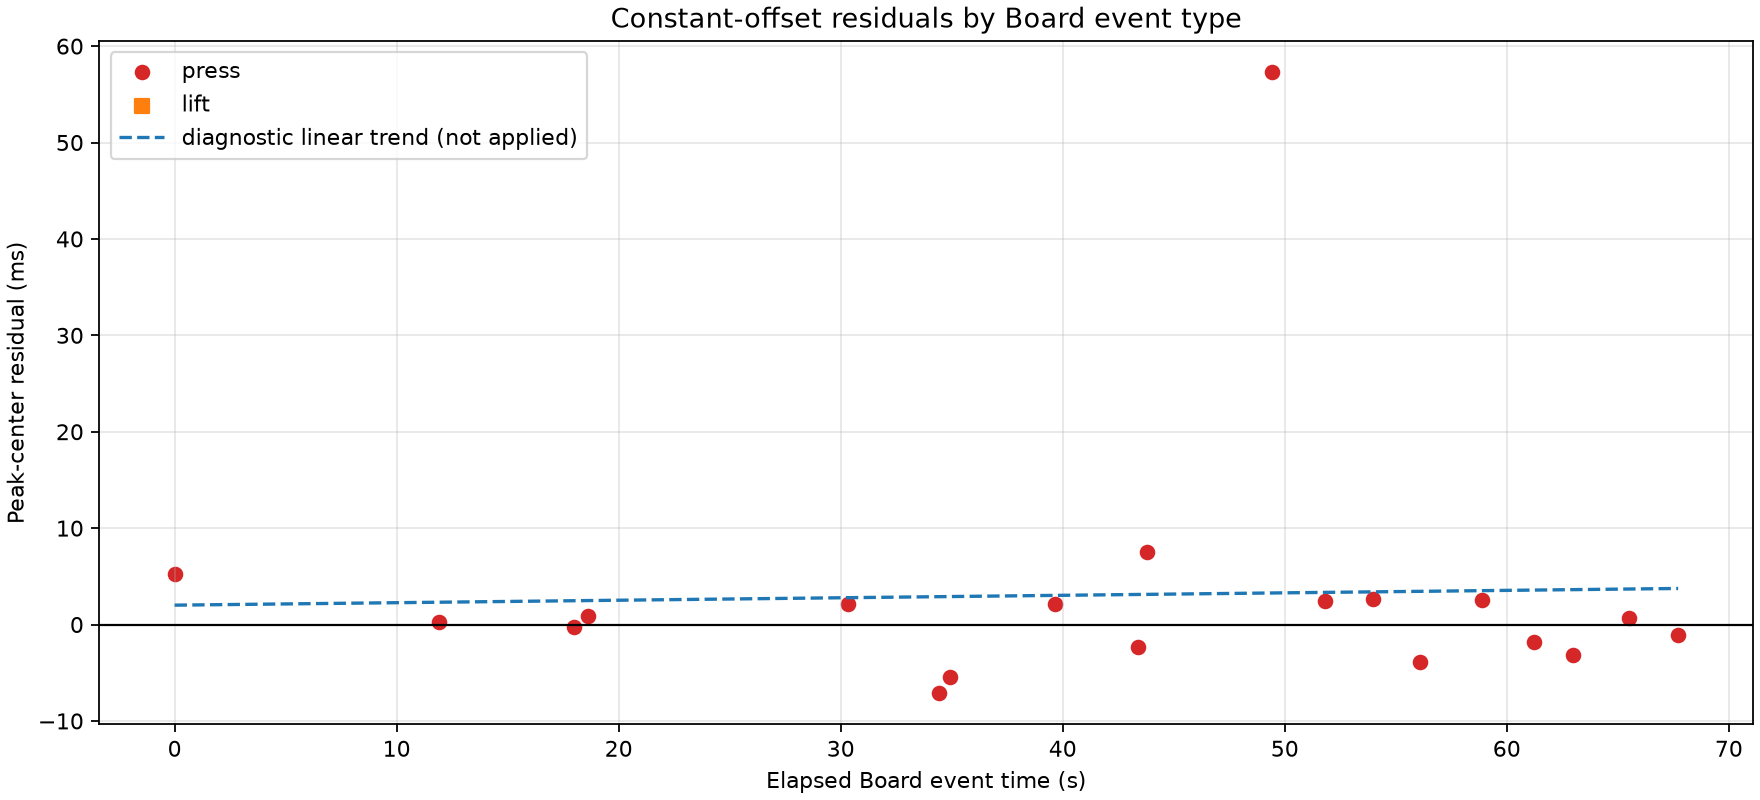

In [53]:
after_imu_path = OUTPUT_DIR / "after_alignment_imu_events_30s.png"
after_transient_path = OUTPUT_DIR / "after_alignment_transient_events_30s.png"
residuals_path = OUTPUT_DIR / "alignment_residuals_press_lift.png"

after_imu_figure, after_visibility = plot_imu_with_board_events(
    ring_dataframe,
    ring_timestamp_reconstructed,
    transient_score,
    board_events_selected,
    signal_columns=active_plot_signal_columns,
    offset_us=alignment_result.best_offset_us,
    duration_s=PREVIEW_DURATION_S,
    title="After alignment: Ring IMU and shifted Board events",
    output_path=after_imu_path,
    show=False,
)
plt.close(after_imu_figure)
after_transient_figure, after_raster_visibility = (
    plot_transient_with_event_raster(
        ring_timestamp_reconstructed,
        transient_score,
        board_events_selected,
        offset_us=alignment_result.best_offset_us,
        duration_s=PREVIEW_DURATION_S,
        title="After alignment: transient score and shifted Board events",
        output_path=after_transient_path,
        show=False,
    )
)
plt.close(after_transient_figure)
assert after_visibility == after_raster_visibility
residual_figure = plot_alignment_residuals(
    event_peak_matches,
    output_path=residuals_path,
    show=False,
)
plt.close(residual_figure)

print(f"After-alignment visibility: {asdict(after_visibility)}")
display(Image(filename=str(after_imu_path)))
display(Image(filename=str(after_transient_path)))
display(Image(filename=str(residuals_path)))

## Machine-readable alignment report and confidence gate

In [54]:
gravity_report = {
    "applied": USE_GRAVITY_REMOVAL,
    "config_template": asdict(GRAVITY_CONFIG_TEMPLATE),
    "stationary_search_config_template": asdict(
        STATIONARY_SEARCH_CONFIG_TEMPLATE
    ),
}
if gravity_result is not None:
    gravity_report.update(
        {
            "effective_config": asdict(gravity_config),
            "effective_stationary_search_config": asdict(
                stationary_search_config
            ),
            "stationary_search": (
                None if gravity_search is None else asdict(gravity_search)
            ),
            "calibration_passed": gravity_result.calibration.passed,
            "provisional": gravity_result.diagnostics.provisional,
        }
    )
combined_warnings = [
    *path_warnings,
    *interval_selection.warnings,
    *gravity_warnings,
    *alignment_result.warnings,
]
alignment_report = {
    "recording": {
        "user": USER,
        "action": ACTION,
        "dataset_id": DATASET_ID,
    },
    "ring_source": str(ring_data.source_path),
    "ring_sampling_rate_hz": imu_sampling_rate_hz,
    "ring_time_axis": (
        "ring_timestamp_reconstructed; microsecond interpretation using "
        "recording-specific endpoint-observed sampling rate"
    ),
    "board_interval": board_interval_metadata,
    "matching_mode": MATCH_EVENT_MODE,
    "configured_matching_event_types": list(alignment_event_types),
    "gravity_removal": gravity_report,
    "transient_score": {
        "input_columns": list(active_transient_signal_columns),
        "gyroscope_included": True,
        "gravity_removal_applied": USE_GRAVITY_REMOVAL,
        "definition": "robust normalized first-difference Euclidean norm",
        "raw_score_retained": True,
        "smoothing_window_samples": TRANSIENT_SMOOTHING_WINDOW_SAMPLES,
        "smoothed_score_used_for_plot_detection_and_matching": True,
    },
    "peak_detection_parameters": asdict(PEAK_CONFIG),
    "alignment_parameters": asdict(ALIGNMENT_CONFIG),
    "transient_peak_region_count": len(transient_peak_regions),
    "offset_candidate_count": len(offset_candidates),
    "before_alignment_visibility": asdict(before_visibility),
    "after_alignment_visibility": asdict(after_visibility),
    "event_data_model": (
        "Board-labelled press/lift events paired by occupancy order; Ring peaks "
        "are unlabeled motion-transient regions."
    ),
    **alignment_result.report,
    "warnings": combined_warnings,
}
alignment_report_path = OUTPUT_DIR / "alignment_report.json"
alignment_report_path.write_text(
    json.dumps(alignment_report, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)
display(alignment_report)

if not alignment_result.success:
    raise AlignmentFailureError(
        "No candidate met the configured minimum alignment confidence; "
        "the best candidate was reported but was not accepted for alignment."
    )

{'recording': {'user': 'user_2', 'action': '0', 'dataset_id': 0},
 'ring_source': '/home/ted/project/writingring-viz/data/user_2/0/0_ring_0.bin',
 'ring_sampling_rate_hz': 200.91323379962884,
 'ring_time_axis': 'ring_timestamp_reconstructed; microsecond interpretation using recording-specific endpoint-observed sampling rate',
 'board_interval': {'board_start_timestamp': 1720653458673257,
  'desired_board_start_timestamp': 1720653457087597,
  'first_available_board_timestamp': 1720653458673257,
  'first_valid_touch_press_timestamp': 1720653460087597,
  'seconds_before_first_valid_touch': 3.0,
  'start_was_clamped': True,
  'desired_board_end_timestamp': 1720653528598073,
  'actual_board_end_timestamp': 1720653528598073,
  'valid_press_count_available': 34,
  'valid_press_count_selected': 21,
  'selected_event_count': 42,
  'selected_press_count': 21,
  'selected_lift_count': 21,
  'end_was_clamped': False,
  'selected_interval_duration_s': 69.924816,
  'target_valid_press_count': 20,
  

## Required consistency and output checks

In [55]:
assert ring_data.source_path.name.endswith("_ring_0.bin")
assert np.all(np.diff(ring_timestamp_reconstructed) > 0.0)
assert tuple(active_plot_signal_columns) == (
    tuple(GRAVITY_REMOVED_SIGNAL_COLUMNS)
    if USE_GRAVITY_REMOVAL
    else tuple(RAW_SIGNAL_COLUMNS)
)
assert tuple(active_transient_signal_columns) == (
    tuple(GRAVITY_REMOVED_TRANSIENT_SIGNAL_COLUMNS)
    if USE_GRAVITY_REMOVAL
    else tuple(RAW_TRANSIENT_SIGNAL_COLUMNS)
)
assert len(transient_score_raw) == len(transient_score) == sample_count
assert np.isfinite(transient_score_raw).all()
assert np.isfinite(transient_score).all()
assert set(event_peak_matches["event_type"]) == set(alignment_event_types)
assert alignment_result.report["matched_event_types"] == list(
    alignment_event_types
)
if USE_GRAVITY_REMOVAL:
    assert gravity_result is not None
    assert np.isfinite(gravity_result.linear_acceleration_body).all()
else:
    assert gravity_result is None
assert not board_events_all.empty
assert not board_events_selected.empty
assert set(board_events_selected["event_type"]) == {"press", "lift"}
assert not (
    (board_events_all.iloc[0]["event_type"] == "press")
    and board_data.frames.iloc[0]["contact_count"] > 0
)
assert board_interval_metadata["target_valid_press_count"] == 20
assert board_interval_metadata["board_start_timestamp"] == max(
    board_interval_metadata["desired_board_start_timestamp"],
    board_interval_metadata["first_available_board_timestamp"],
)
assert alignment_result.success
assert event_peak_matches["event_index"].is_unique
assert event_peak_matches.loc[
    event_peak_matches["matched"], "matched_peak_index"
].is_unique
assert event_peak_matches.loc[
    event_peak_matches["matched"], "matched_peak_timestamp"
].is_monotonic_increasing
assert (
    event_peak_matches.loc[
        event_peak_matches["matched"], "normalized_peak_distance"
    ] <= 1.0 + 1e-12
).all()

required_output_paths = [
    board_events_all_path,
    board_events_selected_path,
    board_touch_pairs_path,
    board_interval_metadata_path,
    transient_peak_regions_path,
    offset_candidates_path,
    event_peak_matches_path,
    touch_pair_matches_path,
    alignment_report_path,
    before_imu_path,
    before_transient_path,
    after_imu_path,
    after_transient_path,
    residuals_path,
]
for output_path in required_output_paths:
    assert output_path.is_file(), f"Missing output: {output_path}"
    assert output_path.stat().st_size > 0, f"Empty output: {output_path}"

print("All automatic event-to-transient alignment checks passed.")
for output_path in required_output_paths:
    print(f"- {output_path.relative_to(PROJECT_ROOT)} ({output_path.stat().st_size:,} bytes)")

All automatic event-to-transient alignment checks passed.
- outputs/alignment/board_events_all.csv (4,114 bytes)
- outputs/alignment/board_events_selected.csv (2,557 bytes)
- outputs/alignment/board_touch_pairs.csv (3,003 bytes)
- outputs/alignment/board_interval_metadata.json (908 bytes)
- outputs/alignment/transient_peak_regions.csv (21,835 bytes)
- outputs/alignment/offset_candidates.csv (12,310 bytes)
- outputs/alignment/event_peak_matches.csv (3,765 bytes)
- outputs/alignment/touch_pair_matches.csv (2,896 bytes)
- outputs/alignment/alignment_report.json (9,137 bytes)
- outputs/alignment/before_alignment_imu_events_30s.png (513,413 bytes)
- outputs/alignment/before_alignment_transient_events_30s.png (102,846 bytes)
- outputs/alignment/after_alignment_imu_events_30s.png (514,141 bytes)
- outputs/alignment/after_alignment_transient_events_30s.png (102,353 bytes)
- outputs/alignment/alignment_residuals_press_lift.png (61,088 bytes)


## Export accepted offset and verify the shared time axis

This cell runs only after the confidence gate. The TXT and six-row PNG consume the same accepted `best_offset_us`; neither operation re-estimates or mutates timestamps.

In [ ]:
from writingring.alignment_io import (
    extract_alignment_offset,
    write_alignment_offset_txt,
)
from writingring.alignment_verification import (
    AlignmentVerificationConfig,
    build_alignment_verification_path,
    create_alignment_verification_figure,
    load_alignment_labels,
    resolve_alignment_label_path,
)

OVERWRITE_ALIGNMENT_EXPORTS = False
LABEL_PATH = None
LABEL_TIME_DOMAIN = "shared"
offset_record = extract_alignment_offset(
    alignment_result,
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
)
offset_path = recording.ring_0_path.parent / f"{DATASET_ID}_ring_board_offset.txt"
write_alignment_offset_txt(
    offset_record, output_path=offset_path, overwrite=OVERWRITE_ALIGNMENT_EXPORTS
)
label_path = resolve_alignment_label_path(
    recording.ring_0_path.parent,
    dataset_id=DATASET_ID,
    explicit_label_path=LABEL_PATH,
)
verification_path = build_alignment_verification_path(
    PROJECT_ROOT / "outputs" / "alignmentVerification",
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
)
verification_result = create_alignment_verification_figure(
    ring_dataframe=ring_dataframe,
    ring_timestamps_us=ring_timestamp_reconstructed,
    transient_score=transient_score,
    board_events=board_events_selected,
    alignment_result=alignment_result,
    labels=load_alignment_labels(label_path),
    label_source_path=label_path,
    output_path=verification_path,
    config=AlignmentVerificationConfig(
        label_time_domain=LABEL_TIME_DOMAIN,
        overwrite=OVERWRITE_ALIGNMENT_EXPORTS,
    ),
    user=USER,
    action=ACTION,
    dataset_id=DATASET_ID,
)
print(f"Alignment offset: {offset_record.offset_us:.6f} us")
print(f"Offset file: {offset_path}")
print(f"Verification image: {verification_result.output_path}")
print(
    f"Displayed: 6 vertically stacked 10-second segments; press={verification_result.press_count_displayed}; "
    f"lift={verification_result.lift_count_displayed}; labels={verification_result.label_count_displayed}"
)

## Interpretation limits

- Board press/lift labels come only from occupancy transitions; Ring peaks have no press/lift polarity or semantic label.
- Coverage dominates amplitude. Prominence is compressed and used only after event count, touch-pair completeness, and peak-center proximity.
- Missing Ring responses are allowed; the matcher never forces 100% coverage or assigns events outside peak regions.
- The result is accepted only when configurable coverage and touch-count thresholds pass. File generation and assertions alone do not imply reliability.
- Residual drift is reported but no affine correction, dynamic time warping, or nonlinear time warp is applied.
- `ring_1`, raw timestamp repair, automatic semantic peak labels, and trained classifiers remain out of scope.